In [20]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

## Downloading and loading Dataset

In [12]:
!wget http://www.cl.cam.ac.uk/Research/DTG/attarchive/pub/data/att_faces.zip
!unzip -q att_faces.zip -d faces_dataset
!rm att_faces.zip

URL transformed to HTTPS due to an HSTS policy
--2026-02-25 19:17:43--  https://www.cl.cam.ac.uk/Research/DTG/attarchive/pub/data/att_faces.zip
Resolving www.cl.cam.ac.uk (www.cl.cam.ac.uk)... 128.232.0.20, 2a05:b400:110::80:14
Connecting to www.cl.cam.ac.uk (www.cl.cam.ac.uk)|128.232.0.20|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.cl.cam.ac.uk/research/dtg/attarchive/pub/data/att_faces.zip [following]
--2026-02-25 19:17:44--  https://www.cl.cam.ac.uk/research/dtg/attarchive/pub/data/att_faces.zip
Reusing existing connection to www.cl.cam.ac.uk:443.
HTTP request sent, awaiting response... 200 OK
Length: 3769022 (3.6M) [application/zip]
Saving to: ‘att_faces.zip’

att_faces.zip       100%[===================>]   3.59M  4.41MB/s    in 0.8s    

2026-02-25 19:17:45 (4.41 MB/s) - ‘att_faces.zip’ saved [3769022/3769022]

replace faces_dataset/README? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [13]:
def load_pgm_data(dataset_path='att_faces'):
    images = []
    labels = []
    
    # Get all person directories sorted
    person_dirs = sorted([d for d in os.listdir(dataset_path) 
                         if os.path.isdir(os.path.join(dataset_path, d))])
    
    for person_id, person_dir in enumerate(person_dirs):
        person_path = os.path.join(dataset_path, person_dir)
        
        # Get all PGM files in this person's directory
        pgm_files = sorted([f for f in os.listdir(person_path) 
                           if f.endswith('.pgm')])
        
        # Load each image
        for pgm_file in pgm_files:
            img_path = os.path.join(person_path, pgm_file)
            img = Image.open(img_path)
            img_array = np.array(img).flatten()  # Flatten to 1D
            images.append(img_array)
            labels.append(person_id)
    
    return np.array(images), np.array(labels)

# Load the data
X, y = load_pgm_data('faces_dataset')
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Dataset shape: {X.shape}")
print(f"Number of people: {len(np.unique(y))}")
print(f"Images per person: {len(y) // len(np.unique(y))}")


X shape: (400, 10304), y shape: (400,)
Dataset shape: (400, 10304)
Number of people: 40
Images per person: 10


## Doing PCA

In [14]:
features_mean = np.mean(X, axis=0)
features_std = np.std(X, axis=0)
X_normalized = (X - features_mean) / features_std

S = np.dot(X_normalized, X_normalized.T)

eigenvalues, eigenvectors = np.linalg.eigh(S)

# Sort both eigenvalues and eigenvectors in descending order of eigenvalues
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

norms = np.linalg.norm(eigenvectors, axis=0)
eigenvectors = eigenvectors / norms

Number of components to capture 95% variance: 192


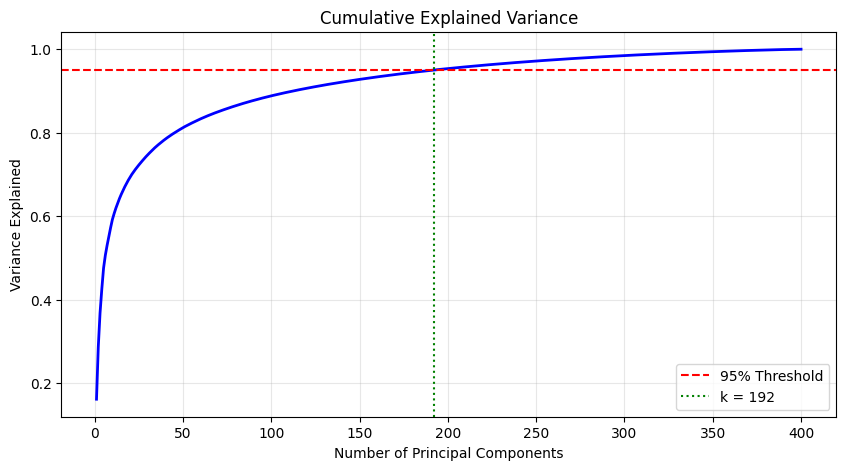

In [15]:
# Calculate cumulative explained variance
exp_var_ratio = eigenvalues / np.sum(eigenvalues)
cum_var = np.cumsum(exp_var_ratio)

# Find how many components we need for 95%
k = np.argmax(cum_var >= 0.95) + 1
print(f"Number of components to capture 95% variance: {k}")

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, color='blue', lw=2)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Threshold')
plt.axvline(x=k, color='green', linestyle=':', label=f'k = {k}')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# W for features
W_large = np.dot(X_normalized.T, eigenvectors)
W_normalized = W_large / np.linalg.norm(W_large, axis=0)

W_k = W_normalized[:, :k] 

X_reduced = np.dot(X_normalized, W_k)
print(f"Original shape: {X.shape}, Reduced shape: {X_reduced.shape}")

Original shape: (400, 10304), Reduced shape: (400, 192)


In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

def train_and_evaluate(X, y, n_neighbors=3, test_size=0.2):
    # 1. Stratified Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    
    # 2. Initialize k-NN
    # n_neighbors=3 is a good starting point for 10 images per person
    # metric='euclidean' or 'cosine' work best for PCA-reduced data
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric='euclidean')
    
    # 3. Train (k-NN just stores the data)
    knn.fit(X_train, y_train)
    
    # 4. Predict
    y_pred = knn.predict(X_test)
    
    # 5. Results
    acc = accuracy_score(y_test, y_pred)
    print(f"k-NN Accuracy (n_neighbors={n_neighbors}): {acc:.4f}")
    print("\nDetailed Performance Metrics (Precision, Recall, F1-Score):")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # 5. Confusion Matrix Visualization
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=False, cmap='Greens')
    plt.title(f'k-NN Confusion Matrix (n_neighbors={n_neighbors})')
    plt.xlabel('Predicted Person ID')
    plt.ylabel('True Person ID')
    plt.show()
    return knn

k-NN Accuracy (n_neighbors=3): 0.8950

Detailed Performance Metrics (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       0.56      1.00      0.71         5
           7       1.00      0.60      0.75         5
           8       0.71      1.00      0.83         5
           9       1.00      0.60      0.75         5
          10       1.00      0.80      0.89         5
          11       1.00      1.00      1.00         5
          12       1.00      1.00      1.00         5
          13       0.83      1.00      0.91         5
          14       1.00      1.00      1.00         5
          15       0.83      1.00   

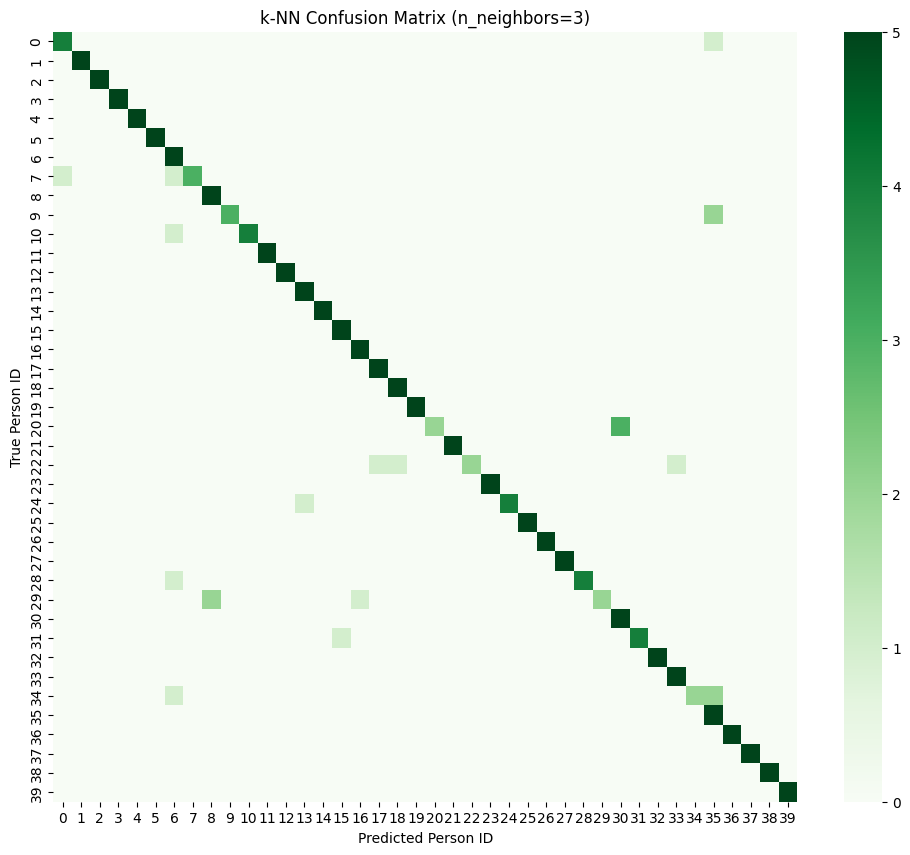

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [52]:
train_and_evaluate(X_reduced, y, n_neighbors=3, test_size=0.5)

k-NN Accuracy (n_neighbors=3): 0.8750

Detailed Performance Metrics (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      1.00      1.00         5
           2       1.00      0.60      0.75         5
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       0.62      1.00      0.77         5
           7       1.00      0.60      0.75         5
           8       0.71      1.00      0.83         5
           9       0.75      0.60      0.67         5
          10       0.50      0.80      0.62         5
          11       1.00      1.00      1.00         5
          12       1.00      1.00      1.00         5
          13       0.71      1.00      0.83         5
          14       1.00      1.00      1.00         5
          15       0.75      0.60   

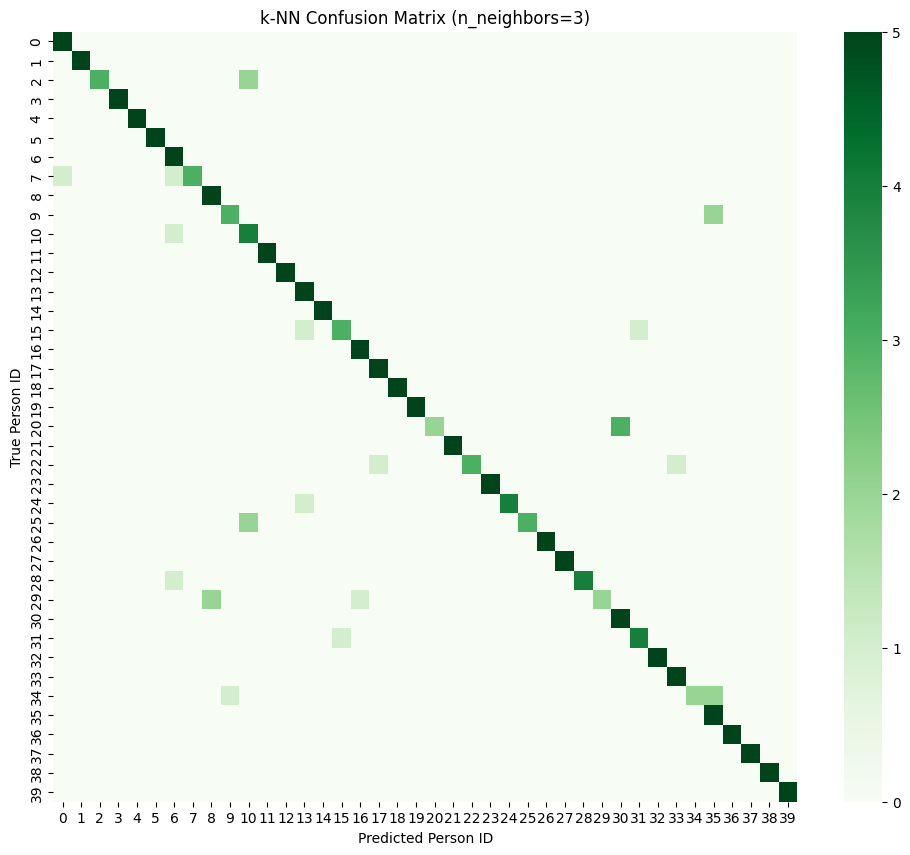

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [50]:
train_and_evaluate(X, y, n_neighbors=3, test_size=0.5)